# 1. Data Engineering & Quality 

**Autor:** Santiago Pereyra  
**Challenge:** Tekne Data Labs — Data & AI Challenge  
**Dataset:** Insurance Claims Fraud Detection  
**Fecha:** 12 de Abril de 2026

---

## Objetivo de este notebook

Este notebook cubre el **punto 1 del challenge**: Data Engineering & Quality.

**Lo que se hace acá:**
1. Instalación de todas las dependencias necesarias
2. Extracción del archivo ZIP con los 3 CSVs del dataset
3. Exploración inicial de cada tabla (shape, tipos, nulls, duplicados)
4. Descripción del modelo de datos (qué es cada tabla, cómo se relacionan)
5. Documentación de problemas de calidad encontrados y cómo se resolvieron
6. Normalización y limpieza de las 3 tablas
7. Persistencia en formato **Parquet** (optimizado para análisis)
8. Integración de las 3 tablas en un dataset consolidado
9. Cálculo de features derivadas temporales
10. Consultas SQL (vía DuckDB) contra las tablas Parquet

Al final de este notebook, las 3 tablas quedan listas en formato Parquet para ser consumidas en los puntos 2, 3 y 4.

---


## 1.1 Instalación de dependencias

Se instalan todas las librerías necesarias para este notebook y los siguientes.


In [2]:
# =============================================================================
# INSTALACIÓN DE LIBRERÍAS
# =============================================================================
# pandas       → manipulación de DataFrames
# numpy        → operaciones numéricas
# matplotlib   → gráficos estáticos
# seaborn      → gráficos estadísticos (wrapper de matplotlib)
# pyarrow      → lectura/escritura de archivos Parquet
# duckdb       → motor SQL en memoria para consultas sobre Parquet
# scikit-learn → para el modelo predictivo del punto 2
# openpyxl     → por si necesitamos exportar a Excel

!pip install pandas numpy matplotlib seaborn pyarrow duckdb scikit-learn openpyxl --quiet

print("Todas las dependencias instaladas correctamente")


Todas las dependencias instaladas correctamente


In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
import duckdb
import zipfile
import os
import warnings

# Configuración global
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

# Directorio de trabajo
WORK_DIR = '.'                        # donde se trabaja
DATA_DIR = os.path.join(WORK_DIR, 'data')     # donde van los CSVs extraídos
PARQUET_DIR = os.path.join(WORK_DIR, 'parquet')  # donde van los Parquets limpios
ZIP_FILE = 'archive.zip'              # archivo fuente

# Crear directorios si no existen
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PARQUET_DIR, exist_ok=True)

print(f"pandas:   {pd.__version__}")
print(f"numpy:    {np.__version__}")
print(f"pyarrow:  {pa.__version__}")
print(f"duckdb:   {duckdb.__version__}")
print(f"\n Imports y configuración listos")
print(f"   DATA_DIR:    {os.path.abspath(DATA_DIR)}")
print(f"   PARQUET_DIR: {os.path.abspath(PARQUET_DIR)}")


pandas:   3.0.2
numpy:    2.4.4
pyarrow:  23.0.1
duckdb:   1.5.1

✅ Imports y configuración listos
   DATA_DIR:    c:\Users\Ash\Downloads\data
   PARQUET_DIR: c:\Users\Ash\Downloads\parquet


## 1.2 Extracción del archivo ZIP

El dataset viene en un archivo `archive.zip` que contiene 3 archivos CSV:
- `insurance_data.csv` — datos transaccionales de claims
- `employee_data.csv` — maestro de agentes/ajustadores
- `vendor_data.csv` — maestro de vendors investigadores


In [3]:
# =============================================================================
# EXTRACCIÓN DEL ZIP
# =============================================================================
# Abrimos el archivo ZIP y listamos su contenido antes de extraer

with zipfile.ZipFile(ZIP_FILE, 'r') as z:
    # Listar contenido del ZIP
    print("=== CONTENIDO DEL ZIP ===")
    for info in z.infolist():
        print(f"  {info.filename:30s}  {info.file_size:>10,} bytes  ({info.file_size/1024:.1f} KB)")
    
    # Extraer todo al directorio de datos
    z.extractall(DATA_DIR)

# Verificar que los 3 archivos se extrajeron correctamente
expected_files = ['insurance_data.csv', 'employee_data.csv', 'vendor_data.csv']
for f in expected_files:
    path = os.path.join(DATA_DIR, f)
    size = os.path.getsize(path)
    print(f"\n✅ {f:25s} → {size:>10,} bytes  OK")

print(f"\n✅ Extracción completa en: {os.path.abspath(DATA_DIR)}")


=== CONTENIDO DEL ZIP ===
  employee_data.csv                  129,541 bytes  (126.5 KB)
  insurance_data.csv               2,938,488 bytes  (2869.6 KB)
  vendor_data.csv                     42,460 bytes  (41.5 KB)



✅ insurance_data.csv        →  2,938,488 bytes  OK

✅ employee_data.csv         →    129,541 bytes  OK

✅ vendor_data.csv           →     42,460 bytes  OK

✅ Extracción completa en: /home/claude/data


## 1.3 Carga de los CSVs en DataFrames

Se cargan los 3 archivos CSV en DataFrames de pandas para inspección inicial.


In [4]:
# =============================================================================
# CARGA DE CSVs
# =============================================================================
# Se cargan sin transformar nada todavía — primero queremos ver el estado "crudo"

insurance_raw = pd.read_csv(os.path.join(DATA_DIR, 'insurance_data.csv'))
employee_raw  = pd.read_csv(os.path.join(DATA_DIR, 'employee_data.csv'))
vendor_raw    = pd.read_csv(os.path.join(DATA_DIR, 'vendor_data.csv'))

print("=== TABLAS CARGADAS ===")
print(f"insurance_data : {insurance_raw.shape[0]:>6,} filas × {insurance_raw.shape[1]:>2} columnas")
print(f"employee_data  : {employee_raw.shape[0]:>6,} filas × {employee_raw.shape[1]:>2} columnas")
print(f"vendor_data    : {vendor_raw.shape[0]:>6,} filas × {vendor_raw.shape[1]:>2} columnas")


=== TABLAS CARGADAS ===
insurance_data : 10,000 filas × 38 columnas
employee_data  :  1,200 filas × 10 columnas
vendor_data    :    600 filas ×  7 columnas


## 1.4 Exploración inicial de cada tabla

### 1.4.1 insurance_data — Tabla de hechos (transaccional)

Esta es la tabla principal. Cada fila es un **claim** (solicitud de reembolso por siniestro) presentado por un cliente a la aseguradora. Contiene:
- Datos de la transacción (ID, fechas)
- Datos del cliente (nombre, dirección, SSN, demografía)
- Datos de la póliza (número, tipo, prima)
- Datos del incidente (severidad, autoridad contactada, lesiones)
- Resultado del claim (CLAIM_STATUS: A=Approved, D=Denied)
- Agente y vendor asignados (FK a las otras tablas)


In [5]:
# =============================================================================
# EXPLORACIÓN: INSURANCE_DATA
# =============================================================================

print("=" * 80)
print("INSURANCE_DATA — Primeras 5 filas")
print("=" * 80)
display(insurance_raw.head())


INSURANCE_DATA — Primeras 5 filas


,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,CUSTOMER_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,SSN,MARITAL_STATUS,AGE,TENURE,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,RISK_SEGMENTATION,HOUSE_TYPE,SOCIAL_CLASS,ROUTING_NUMBER,ACCT_NUMBER,CUSTOMER_EDUCATION_LEVEL,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID
0,2020-06-01 00:00:00,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,Christopher Demarest,7701 West Saint John Road,#2010,Glendale,AZ,85308,087-11-1946,Y,54,89,Y,3,L,Own,LI,109134974,HXJP58258181908465,Bachelor,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556
1,2020-06-01 00:00:00,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,Ricardo Gatlin,8595 West 81st Drive,NaN,Arvada,CO,80005,685-33-3536,N,61,80,Y,4,L,Rent,MI,40125819,JUND46859540983731,Bachelor,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592
2,2020-06-01 00:00:00,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,Lashawn Engles,637 Britannia Drive,NaN,Vallejo,CA,94591,378-36-0672,N,47,68,Y,6,L,Rent,MI,99513168,WGZZ90128415227650,PhD,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031
3,2020-06-01 00:00:00,TXN00000004,A00007572,PLC00009292,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,Steven Bassett,2803 River Drive,NaN,Thunderbolt,GA,31404,669-92-1861,Y,36,16,Y,7,L,Mortgage,MI,18429110,WIKE91555436351397,Masters,A,Minor Loss,Ambulance,0,0,GA,Savannah,12,AGENT00278,VNDR00075
4,2020-06-01 00:00:00,TXN00000005,A00008173,PLC00000204,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,Jason Rodriguez,7573 National Drive,NaN,Livermore,CA,94550,703-40-1033,Y,51,16,Y,2,M,Rent,HI,70752391,VYJW71311537294027,Masters,A,Major Loss,Police,0,1,TN,Nashville,18,AGENT00636,VNDR00472


In [6]:
# --- Tipos de dato ---
print("=== TIPOS DE DATO ===")
print(insurance_raw.dtypes)
print(f"\nTotal columnas: {len(insurance_raw.columns)}")


=== TIPOS DE DATO ===
TXN_DATE_TIME                   str
TRANSACTION_ID                  str
CUSTOMER_ID                     str
POLICY_NUMBER                   str
POLICY_EFF_DT                   str
LOSS_DT                         str
REPORT_DT                       str
INSURANCE_TYPE                  str
PREMIUM_AMOUNT              float64
CLAIM_AMOUNT                  int64
CUSTOMER_NAME                   str
ADDRESS_LINE1                   str
ADDRESS_LINE2                   str
CITY                            str
STATE                           str
POSTAL_CODE                   int64
SSN                             str
MARITAL_STATUS                  str
AGE                           int64
TENURE                        int64
EMPLOYMENT_STATUS               str
NO_OF_FAMILY_MEMBERS          int64
RISK_SEGMENTATION               str
HOUSE_TYPE                      str
SOCIAL_CLASS                    str
ROUTING_NUMBER                int64
ACCT_NUMBER                     str
CUSTOM

In [7]:
# --- Análisis de Nulls ---
print("=== NULLS POR COLUMNA ===")
nulls = insurance_raw.isnull().sum()
nulls_pct = (insurance_raw.isnull().mean() * 100).round(2)
null_report = pd.DataFrame({'nulls': nulls, 'pct': nulls_pct})
null_report = null_report[null_report['nulls'] > 0].sort_values('nulls', ascending=False)
print(null_report)
print(f"\nTotal columnas con nulls: {len(null_report)}")


=== NULLS POR COLUMNA ===
                          nulls   pct
ADDRESS_LINE2              8505 85.05
VENDOR_ID                  3245 32.45
AUTHORITY_CONTACTED        1945 19.45
CUSTOMER_EDUCATION_LEVEL    529  5.29
CITY                         54  0.54
INCIDENT_CITY                46  0.46

Total columnas con nulls: 6


In [8]:
# --- Duplicados ---
print("=== DUPLICADOS ===")
print(f"Filas completamente duplicadas:  {insurance_raw.duplicated().sum()}")
print(f"TRANSACTION_ID duplicados:       {insurance_raw['TRANSACTION_ID'].duplicated().sum()}")
print(f"CUSTOMER_ID duplicados:          {insurance_raw['CUSTOMER_ID'].duplicated().sum()}")
print(f"POLICY_NUMBER duplicados:        {insurance_raw['POLICY_NUMBER'].duplicated().sum()}")
print(f"SSN duplicados:                  {insurance_raw['SSN'].duplicated().sum()}")
print("\n→ No hay duplicados. Cada fila es un claim único.")


=== DUPLICADOS ===
Filas completamente duplicadas:  0
TRANSACTION_ID duplicados:       0
CUSTOMER_ID duplicados:          0
POLICY_NUMBER duplicados:        0
SSN duplicados:                  0

→ No hay duplicados. Cada fila es un claim único.


In [9]:
# --- Cardinalidad de cada columna ---
print("=== CARDINALIDAD (valores únicos por columna) ===")
for col in insurance_raw.columns:
    n = insurance_raw[col].nunique()
    print(f"  {col:35s} {n:>7,} únicos")


=== CARDINALIDAD (valores únicos por columna) ===
  TXN_DATE_TIME                           395 únicos
  TRANSACTION_ID                       10,000 únicos
  CUSTOMER_ID                          10,000 únicos
  POLICY_NUMBER                        10,000 únicos
  POLICY_EFF_DT                         3,306 únicos
  LOSS_DT                                 414 únicos
  REPORT_DT                               409 únicos
  INSURANCE_TYPE                            6 únicos
  PREMIUM_AMOUNT                        6,550 únicos
  CLAIM_AMOUNT                            107 únicos


  CUSTOMER_NAME                         9,880 únicos
  ADDRESS_LINE1                         3,092 únicos
  ADDRESS_LINE2                           256 únicos
  CITY                                    412 únicos
  STATE                                    16 únicos
  POSTAL_CODE                             669 únicos
  SSN                                  10,000 únicos
  MARITAL_STATUS                            2 únicos
  AGE                                      40 únicos
  TENURE                                  114 únicos
  EMPLOYMENT_STATUS                         2 únicos
  NO_OF_FAMILY_MEMBERS                      6 únicos
  RISK_SEGMENTATION                         3 únicos
  HOUSE_TYPE                                3 únicos
  SOCIAL_CLASS                              3 únicos
  ROUTING_NUMBER                        9,995 únicos
  ACCT_NUMBER                          10,000 únicos
  CUSTOMER_EDUCATION_LEVEL                  6 únicos
  CLAIM_STATUS                              2 

In [10]:
# --- Estadísticas de columnas numéricas ---
print("=== ESTADÍSTICAS NUMÉRICAS ===")
display(insurance_raw.describe())


=== ESTADÍSTICAS NUMÉRICAS ===


,PREMIUM_AMOUNT,CLAIM_AMOUNT,POSTAL_CODE,AGE,TENURE,NO_OF_FAMILY_MEMBERS,ROUTING_NUMBER,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_HOUR_OF_THE_DAY
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,88.51,16563.83,48288.83,44.47,62.95,4.49,70528823.17,0.70,0.69,11.60
std,48.32,22037.49,32467.39,11.52,32.89,1.71,34518785.85,0.46,0.46,6.88
min,6.00,100.00,1001.00,25.00,6.00,2.00,10000744.00,0.00,0.00,0.00
25%,62.02,2000.00,21061.00,34.00,34.00,3.00,40717614.00,0.00,0.00,6.00
50%,88.84,7000.00,37206.00,45.00,64.00,4.00,70366137.00,1.00,1.00,12.00
75%,121.90,21000.00,80004.00,54.00,92.00,6.00,100063761.75,1.00,1.00,18.00
max,200.00,100000.00,99669.00,64.00,119.00,7.00,129998077.00,1.00,1.00,23.00


In [11]:
# --- Distribución de columnas categóricas clave ---
print("=== DISTRIBUCIÓN DE CATEGORÍAS ===")
cat_cols = ['INSURANCE_TYPE', 'CLAIM_STATUS', 'INCIDENT_SEVERITY', 'MARITAL_STATUS',
            'EMPLOYMENT_STATUS', 'RISK_SEGMENTATION', 'HOUSE_TYPE', 'SOCIAL_CLASS',
            'CUSTOMER_EDUCATION_LEVEL', 'AUTHORITY_CONTACTED']

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(insurance_raw[col].value_counts(dropna=False))


=== DISTRIBUCIÓN DE CATEGORÍAS ===

--- INSURANCE_TYPE ---


INSURANCE_TYPE
Property    1692
Mobile      1692
Health      1690
Life        1682
Travel      1670
Motor       1574
Name: count, dtype: int64

--- CLAIM_STATUS ---
CLAIM_STATUS
A    9497
D     503
Name: count, dtype: int64

--- INCIDENT_SEVERITY ---
INCIDENT_SEVERITY
Total Loss    3390
Major Loss    3317
Minor Loss    3293
Name: count, dtype: int64

--- MARITAL_STATUS ---
MARITAL_STATUS
Y    7224
N    2776
Name: count, dtype: int64

--- EMPLOYMENT_STATUS ---
EMPLOYMENT_STATUS
Y    9171
N     829
Name: count, dtype: int64

--- RISK_SEGMENTATION ---
RISK_SEGMENTATION
L    4395
M    4150
H    1455
Name: count, dtype: int64

--- HOUSE_TYPE ---
HOUSE_TYPE
Mortgage    3652
Rent        3385
Own         2963
Name: count, dtype: int64

--- SOCIAL_CLASS ---
SOCIAL_CLASS
MI    4794
LI    2727
HI    2479
Name: count, dtype: int64

--- CUSTOMER_EDUCATION_LEVEL ---
CUSTOMER_EDUCATION_LEVEL
Bachelor       3991
High School    2385
Masters        1045
College        1035
MD              539
NaN       

### 1.4.2 employee_data — Tabla maestra de agentes

Cada fila es un **agente/ajustador** que trabaja en la aseguradora. Tiene:
- ID del agente (`AGENT_ID`)
- Nombre, dirección, datos bancarios
- Fecha de ingreso (`DATE_OF_JOINING`)


In [12]:
# =============================================================================
# EXPLORACIÓN: EMPLOYEE_DATA
# =============================================================================

print("=" * 80)
print("EMPLOYEE_DATA — Primeras 5 filas")
print("=" * 80)
display(employee_raw.head())

print("\n=== TIPOS DE DATO ===")
print(employee_raw.dtypes)

print("\n=== NULLS ===")
print(employee_raw.isnull().sum())

print(f"\n=== DUPLICADOS ===")
print(f"AGENT_ID duplicados: {employee_raw['AGENT_ID'].duplicated().sum()}")

print(f"\n=== DATE_OF_JOINING rango ===")
emp_dates = pd.to_datetime(employee_raw['DATE_OF_JOINING'])
print(f"Desde: {emp_dates.min()}")
print(f"Hasta: {emp_dates.max()}")

print(f"\n=== POSTAL_CODE como int (posible pérdida de leading zeros) ===")
print(f"ZIP < 10000: {(employee_raw['POSTAL_CODE'] < 10000).sum()} de {len(employee_raw)}")


EMPLOYEE_DATA — Primeras 5 filas


,AGENT_ID,AGENT_NAME,DATE_OF_JOINING,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER
0,AGENT00001,Ray Johns,1993-06-05,1402 Maggies Way,NaN,Waterbury Center,VT,5677,34584958,HKUN51252328472585
1,AGENT00002,Angelo Borjon,2005-12-27,414 Tanya Pass,NaN,Panama City,FL,32404,107363763,OPIS19290040088204
2,AGENT00003,Candy Spellman,2003-09-02,606 National Street,#306,Fayetteville,AR,72701,81744097,YSCJ67489688482590
3,AGENT00004,Mary Smith,2004-09-23,235 Hugh Thomas Drive,NaN,Panama City,FL,32404,67563771,ZANG21285355574581
4,AGENT00005,Mildred Diaz,2011-06-21,3426 Broadview Street,NaN,Montgomery,AL,36110,114951317,DZFS82244494451134



=== TIPOS DE DATO ===
AGENT_ID                str
AGENT_NAME              str
DATE_OF_JOINING         str
ADDRESS_LINE1           str
ADDRESS_LINE2           str
CITY                    str
STATE                   str
POSTAL_CODE           int64
EMP_ROUTING_NUMBER    int64
EMP_ACCT_NUMBER         str
dtype: object

=== NULLS ===


AGENT_ID                 0
AGENT_NAME               0
DATE_OF_JOINING          0
ADDRESS_LINE1            0
ADDRESS_LINE2         1021
CITY                     7
STATE                    0
POSTAL_CODE              0
EMP_ROUTING_NUMBER       0
EMP_ACCT_NUMBER          0
dtype: int64

=== DUPLICADOS ===
AGENT_ID duplicados: 0

=== DATE_OF_JOINING rango ===
Desde: 1990-06-25 00:00:00
Hasta: 2018-06-24 00:00:00

=== POSTAL_CODE como int (posible pérdida de leading zeros) ===
ZIP < 10000: 201 de 1200


### 1.4.3 vendor_data — Tabla maestra de vendors

Cada fila es un **vendor** (empresa investigadora externa) que asiste a la aseguradora en la investigación de claims sospechosos. Solo tiene:
- ID del vendor (`VENDOR_ID`)
- Nombre de la empresa
- Dirección


In [13]:
# =============================================================================
# EXPLORACIÓN: VENDOR_DATA
# =============================================================================

print("=" * 80)
print("VENDOR_DATA — Primeras 5 filas")
print("=" * 80)
display(vendor_raw.head())

print("\n=== TIPOS DE DATO ===")
print(vendor_raw.dtypes)

print("\n=== NULLS ===")
print(vendor_raw.isnull().sum())

print(f"\n=== DUPLICADOS ===")
print(f"VENDOR_ID duplicados: {vendor_raw['VENDOR_ID'].duplicated().sum()}")

print(f"\n=== POSTAL_CODE como int ===")
print(f"ZIP < 10000: {(vendor_raw['POSTAL_CODE'] < 10000).sum()} de {len(vendor_raw)}")


VENDOR_DATA — Primeras 5 filas


,VENDOR_ID,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,VNDR00001,"King, Proctor and Jones",2027 North Shannon Drive,#5,Fayetteville,AR,72703
1,VNDR00002,Garcia Ltd,5701 East Shirley Lane,NaN,Montgomery,AL,36117
2,VNDR00003,Cherry LLC,1217 Cottondale Road,NaN,Montgomery,AL,36109
3,VNDR00004,Mays-Benson,227 West Montgomery Cross Road,#736,Savannah,GA,31406
4,VNDR00005,Wilson PLC,23 North Hill Street,NaN,Nashville,TN,37210



=== TIPOS DE DATO ===
VENDOR_ID          str
VENDOR_NAME        str
ADDRESS_LINE1      str
ADDRESS_LINE2      str
CITY               str
STATE              str
POSTAL_CODE      int64
dtype: object

=== NULLS ===
VENDOR_ID          0
VENDOR_NAME        0
ADDRESS_LINE1      0
ADDRESS_LINE2    503
CITY               6
STATE              0
POSTAL_CODE        0
dtype: int64

=== DUPLICADOS ===
VENDOR_ID duplicados: 0

=== POSTAL_CODE como int ===
ZIP < 10000: 105 de 600


## 1.5 Modelo de datos

### Diagrama de relaciones

```
┌─────────────────────┐        ┌──────────────────┐
│   employee_data     │        │   vendor_data     │
│   (maestro agentes) │        │   (maestro vendor)│
│                     │        │                   │
│   PK: AGENT_ID      │        │   PK: VENDOR_ID   │
│   1,200 registros   │        │   600 registros   │
└──────────┬──────────┘        └──────────┬────────┘
           │ 1                            │ 1
           │                              │
           │ N                            │ N (nullable)
┌──────────┴──────────────────────────────┴────────┐
│                insurance_data                     │
│              (tabla transaccional)                │
│                                                   │
│   PK: TRANSACTION_ID                              │
│   FK: AGENT_ID    → employee_data.AGENT_ID        │
│   FK: VENDOR_ID   → vendor_data.VENDOR_ID (NULL)  │
│   10,000 registros                                │
└───────────────────────────────────────────────────┘
```

### Descripción de cada tabla

| Tabla | Tipo | Granularidad | PK | FKs | Registros |
|-------|------|-------------|-----|-----|----------:|
| `insurance_data` | Hechos (transaccional) | 1 fila = 1 claim | `TRANSACTION_ID` | `AGENT_ID`, `VENDOR_ID` | 10,000 |
| `employee_data` | Dimensión (maestro) | 1 fila = 1 agente | `AGENT_ID` | — | 1,200 |
| `vendor_data` | Dimensión (maestro) | 1 fila = 1 vendor | `VENDOR_ID` | — | 600 |

### Relaciones
- `insurance_data.AGENT_ID` → `employee_data.AGENT_ID` (N:1, obligatorio, sin nulls)
- `insurance_data.VENDOR_ID` → `vendor_data.VENDOR_ID` (N:1, opcional, 32.5% null = no se asignó vendor)
- Todos los IDs de FK en insurance_data existen en sus respectivas tablas maestras (integridad OK)
- No hay agentes ni vendors huérfanos (todos tienen al menos 1 claim)


In [14]:
# =============================================================================
# VALIDACIÓN DE INTEGRIDAD REFERENCIAL
# =============================================================================

# Sets de IDs para comparar
agents_in_insurance = set(insurance_raw['AGENT_ID'].unique())
agents_in_employee  = set(employee_raw['AGENT_ID'].unique())
vendors_in_insurance = set(insurance_raw['VENDOR_ID'].dropna().unique())
vendors_in_vendor   = set(vendor_raw['VENDOR_ID'].unique())

print("=== INTEGRIDAD REFERENCIAL ===")
print(f"")
print(f"AGENT_ID:")
print(f"  Agentes en insurance_data:               {len(agents_in_insurance):,}")
print(f"  Agentes en employee_data:                {len(agents_in_employee):,}")
print(f"  Agentes en insurance SIN match employee: {len(agents_in_insurance - agents_in_employee)}")
print(f"  Agentes en employee SIN claims:          {len(agents_in_employee - agents_in_insurance)}")
print(f"")
print(f"VENDOR_ID:")
print(f"  Vendors en insurance_data (no null):     {len(vendors_in_insurance):,}")
print(f"  Vendors en vendor_data:                  {len(vendors_in_vendor):,}")
print(f"  Vendors en insurance SIN match vendor:   {len(vendors_in_insurance - vendors_in_vendor)}")
print(f"  Claims sin vendor asignado (NULL):       {insurance_raw['VENDOR_ID'].isnull().sum():,} ({insurance_raw['VENDOR_ID'].isnull().mean()*100:.1f}%)")
print(f"")
print("✅ Integridad referencial OK — todos los FKs tienen match en sus maestros")


=== INTEGRIDAD REFERENCIAL ===



AGENT_ID:
  Agentes en insurance_data:               1,200
  Agentes en employee_data:                1,200
  Agentes en insurance SIN match employee: 0
  Agentes en employee SIN claims:          0

VENDOR_ID:
  Vendors en insurance_data (no null):     407
  Vendors en vendor_data:                  600
  Vendors en insurance SIN match vendor:   0
  Claims sin vendor asignado (NULL):       3,245 (32.5%)

✅ Integridad referencial OK — todos los FKs tienen match en sus maestros


## 1.6 Problemas de calidad encontrados y resolución

Se documentan **5 problemas de calidad** encontrados durante la exploración, junto con la decisión tomada para resolverlos.

---

### Problema 1: Fechas almacenadas como `object` (string)

| Atributo | Valor |
|----------|-------|
| **Columnas afectadas** | `TXN_DATE_TIME`, `LOSS_DT`, `REPORT_DT`, `POLICY_EFF_DT` (insurance) + `DATE_OF_JOINING` (employee) |
| **Registros afectados** | 10,000 (100% de insurance) + 1,200 (100% de employee) |
| **Impacto** | Impide cálculos temporales (diferencias de fechas, extracción de mes/año, etc.) |
| **Resolución** | Casteo a `datetime64[ns]` con `pd.to_datetime()` |


### Problema 2: `POSTAL_CODE` almacenado como `int64`, pierde leading zeros

| Atributo | Valor |
|----------|-------|
| **Columnas afectadas** | `POSTAL_CODE` en las 3 tablas |
| **Registros afectados** | 1,722 (insurance) + 201 (employee) + 105 (vendor) |
| **Impacto** | ZIP codes del noreste de EE.UU. (CT, MA, VT, ME, NH, NJ) empiezan con `0`. Al guardarse como `int`, el `06040` se convierte en `6040`. Afecta joins y geolocalización. |
| **Resolución** | Conversión a `str` + `zfill(5)` para restaurar formato de 5 dígitos |


### Problema 3: Nulls significativos en columnas categóricas

| Columna | Nulls | % | Decisión |
|---------|------:|--:|----------|
| `ADDRESS_LINE2` (insurance) | 8,505 | 85.0% | Se mantiene NULL — campo opcional (depto, piso). |
| `VENDOR_ID` (insurance) | 3,245 | 32.5% | Se mantiene NULL (= no se asignó vendor). Se crea flag `HAS_VENDOR`. |
| `AUTHORITY_CONTACTED` (insurance) | 1,945 | 19.5% | Se imputa como `'None'` — no se contactó autoridad. |
| `CUSTOMER_EDUCATION_LEVEL` (insurance) | 529 | 5.3% | Se imputa como `'Unknown'`. |
| `CITY` (insurance) | 54 | 0.5% | Se imputa como `'Unknown'`. |
| `INCIDENT_CITY` (insurance) | 46 | 0.5% | Se imputa como `'Unknown'`. |
| `ADDRESS_LINE2` (employee) | 1,021 | 85.1% | Se mantiene NULL — campo opcional. |
| `CITY` (employee) | 7 | 0.6% | Se imputa como `'Unknown'`. |
| `ADDRESS_LINE2` (vendor) | 503 | 83.8% | Se mantiene NULL — campo opcional. |
| `CITY` (vendor) | 6 | 1.0% | Se imputa como `'Unknown'`. |


### Problema 4: `CLAIM_AMOUNT` tiene solo 107 valores únicos (parece bucketeado)

| Atributo | Valor |
|----------|-------|
| **Registros afectados** | 10,000 (toda la tabla) |
| **Impacto** | Los montos de claims no son continuos sino que están redondeados a valores fijos (100, 200, 500, 600, 700, 1000, 2000, etc.). Esto puede ser un artifact del sistema fuente. |
| **Resolución** | Se documenta como limitación del dato. No se modifica porque puede reflejar la realidad del sistema de carga de la aseguradora (montos tabulados). |


### Problema 5: `TENURE` no correlaciona con la antigüedad real de la póliza

| Atributo | Valor |
|----------|-------|
| **Registros afectados** | 10,000 (toda la tabla) |
| **Impacto** | Al calcular los meses entre `POLICY_EFF_DT` y `TXN_DATE_TIME`, la correlación con `TENURE` es **-0.006** (prácticamente cero). Esto significa que `TENURE` **NO** representa la antigüedad de la póliza. Podría ser antigüedad del cliente, meses de cobertura acumulada, u otro concepto. |
| **Resolución** | Se mantiene `TENURE` tal cual (no hay forma de corregirlo sin documentación del negocio). Se crea feature calculada `POLICY_AGE_YEARS` que sí refleja la antigüedad real. Se documenta la inconsistencia. |


## 1.7 Normalización y limpieza de las 3 tablas

Ahora aplicamos todas las correcciones documentadas arriba. Cada tabla se limpia por separado y se guarda en formato **Parquet**.

### ¿Por qué Parquet?
- **Columnar**: lecturas analíticas son más rápidas (solo lee las columnas que necesitás)
- **Compresión**: ocupa menos espacio que CSV (~3-5x menos)
- **Tipos preservados**: las fechas, enteros y strings se guardan con su tipo correcto (no todo como string como en CSV)
- **Compatible**: lo lee pandas, DuckDB, Spark, BigQuery, etc.

---

### 1.7.1 Limpieza de `insurance_data`


In [15]:
# =============================================================================
# LIMPIEZA: INSURANCE_DATA
# =============================================================================

# Copiamos para no modificar el raw
insurance = insurance_raw.copy()

# ---------------------------------------------------------------
# FIX 1: Castear fechas a datetime
# ---------------------------------------------------------------
date_columns = ['TXN_DATE_TIME', 'LOSS_DT', 'REPORT_DT', 'POLICY_EFF_DT']
for col in date_columns:
    insurance[col] = pd.to_datetime(insurance[col])
    
print("FIX 1 — Fechas casteadas:")
for col in date_columns:
    print(f"  {col}: {insurance[col].dtype}")

# ---------------------------------------------------------------
# FIX 2: POSTAL_CODE a string con leading zeros
# ---------------------------------------------------------------
insurance['POSTAL_CODE'] = insurance['POSTAL_CODE'].astype(str).str.zfill(5)
print(f"\nFIX 2 — POSTAL_CODE a string: tipo={insurance['POSTAL_CODE'].dtype}")
print(f"  Ejemplo CT: {insurance[insurance['STATE']=='CT']['POSTAL_CODE'].iloc[0]}")

# ---------------------------------------------------------------
# FIX 3: Imputar nulls categóricos
# ---------------------------------------------------------------
insurance['AUTHORITY_CONTACTED'] = insurance['AUTHORITY_CONTACTED'].fillna('None')
insurance['CUSTOMER_EDUCATION_LEVEL'] = insurance['CUSTOMER_EDUCATION_LEVEL'].fillna('Unknown')
insurance['CITY'] = insurance['CITY'].fillna('Unknown')
insurance['INCIDENT_CITY'] = insurance['INCIDENT_CITY'].fillna('Unknown')

print(f"\nFIX 3 — Nulls imputados:")
print(f"  AUTHORITY_CONTACTED nulls: {insurance['AUTHORITY_CONTACTED'].isnull().sum()}")
print(f"  CUSTOMER_EDUCATION_LEVEL nulls: {insurance['CUSTOMER_EDUCATION_LEVEL'].isnull().sum()}")
print(f"  CITY nulls: {insurance['CITY'].isnull().sum()}")
print(f"  INCIDENT_CITY nulls: {insurance['INCIDENT_CITY'].isnull().sum()}")

# ---------------------------------------------------------------
# FLAG: HAS_VENDOR (0/1) para claims sin vendor
# ---------------------------------------------------------------
insurance['HAS_VENDOR'] = insurance['VENDOR_ID'].notna().astype(int)
print(f"\nFLAG HAS_VENDOR: 1={insurance['HAS_VENDOR'].sum():,} | 0={(insurance['HAS_VENDOR']==0).sum():,}")

# ---------------------------------------------------------------
# Verificación final
# ---------------------------------------------------------------
print(f"\n=== ESTADO FINAL insurance_data ===")
print(f"Shape: {insurance.shape}")
remaining_nulls = insurance.drop(columns=['VENDOR_ID', 'ADDRESS_LINE2']).isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls) == 0:
    print("✅ Sin nulls en columnas operativas (excepto VENDOR_ID y ADDRESS_LINE2 que son válidos)")
else:
    print(f"⚠️ Nulls restantes: {remaining_nulls.to_dict()}")


FIX 1 — Fechas casteadas:
  TXN_DATE_TIME: datetime64[us]
  LOSS_DT: datetime64[us]
  REPORT_DT: datetime64[us]
  POLICY_EFF_DT: datetime64[us]

FIX 2 — POSTAL_CODE a string: tipo=str


  Ejemplo CT: 06040

FIX 3 — Nulls imputados:
  AUTHORITY_CONTACTED nulls: 0
  CUSTOMER_EDUCATION_LEVEL nulls: 0
  CITY nulls: 0
  INCIDENT_CITY nulls: 0



FLAG HAS_VENDOR: 1=6,755 | 0=3,245

=== ESTADO FINAL insurance_data ===
Shape: (10000, 39)
✅ Sin nulls en columnas operativas (excepto VENDOR_ID y ADDRESS_LINE2 que son válidos)


### 1.7.2 Limpieza de `employee_data`

In [16]:
# =============================================================================
# LIMPIEZA: EMPLOYEE_DATA
# =============================================================================

employee = employee_raw.copy()

# FIX 1: Fecha de ingreso a datetime
employee['DATE_OF_JOINING'] = pd.to_datetime(employee['DATE_OF_JOINING'])
print(f"FIX 1 — DATE_OF_JOINING: {employee['DATE_OF_JOINING'].dtype}")

# FIX 2: POSTAL_CODE a string con leading zeros
employee['POSTAL_CODE'] = employee['POSTAL_CODE'].astype(str).str.zfill(5)
print(f"FIX 2 — POSTAL_CODE: tipo={employee['POSTAL_CODE'].dtype}")

# FIX 3: Imputar CITY null
employee['CITY'] = employee['CITY'].fillna('Unknown')
print(f"FIX 3 — CITY nulls: {employee['CITY'].isnull().sum()}")

print(f"\n=== ESTADO FINAL employee_data ===")
print(f"Shape: {employee.shape}")
print(f"Nulls (sin ADDRESS_LINE2): {employee.drop(columns=['ADDRESS_LINE2']).isnull().sum().sum()}")
print("✅ employee_data limpio")


FIX 1 — DATE_OF_JOINING: datetime64[us]
FIX 2 — POSTAL_CODE: tipo=str


FIX 3 — CITY nulls: 0

=== ESTADO FINAL employee_data ===
Shape: (1200, 10)
Nulls (sin ADDRESS_LINE2): 0
✅ employee_data limpio


### 1.7.3 Limpieza de `vendor_data`

In [17]:
# =============================================================================
# LIMPIEZA: VENDOR_DATA
# =============================================================================

vendor = vendor_raw.copy()

# FIX 1: POSTAL_CODE a string con leading zeros
vendor['POSTAL_CODE'] = vendor['POSTAL_CODE'].astype(str).str.zfill(5)
print(f"FIX 1 — POSTAL_CODE: tipo={vendor['POSTAL_CODE'].dtype}")

# FIX 2: Imputar CITY null
vendor['CITY'] = vendor['CITY'].fillna('Unknown')
print(f"FIX 2 — CITY nulls: {vendor['CITY'].isnull().sum()}")

print(f"\n=== ESTADO FINAL vendor_data ===")
print(f"Shape: {vendor.shape}")
print(f"Nulls (sin ADDRESS_LINE2): {vendor.drop(columns=['ADDRESS_LINE2']).isnull().sum().sum()}")
print("✅ vendor_data limpio")


FIX 1 — POSTAL_CODE: tipo=str
FIX 2 — CITY nulls: 0

=== ESTADO FINAL vendor_data ===
Shape: (600, 7)


Nulls (sin ADDRESS_LINE2): 0
✅ vendor_data limpio


## 1.8 Persistencia en formato Parquet

Se guardan las 3 tablas limpias en formato Parquet. Este es el formato que se consume en los puntos 2, 3 y 4 del challenge.


In [18]:
# =============================================================================
# GUARDADO EN PARQUET
# =============================================================================

# Guardar cada tabla
insurance.to_parquet(os.path.join(PARQUET_DIR, 'insurance_data.parquet'), index=False, engine='pyarrow')
employee.to_parquet(os.path.join(PARQUET_DIR, 'employee_data.parquet'), index=False, engine='pyarrow')
vendor.to_parquet(os.path.join(PARQUET_DIR, 'vendor_data.parquet'), index=False, engine='pyarrow')

# Verificar tamaños
print("=== ARCHIVOS PARQUET GENERADOS ===")
for fname in ['insurance_data.parquet', 'employee_data.parquet', 'vendor_data.parquet']:
    fpath = os.path.join(PARQUET_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:30s} {size_kb:>8.1f} KB")

# Comparar con CSV original
print(f"\n=== COMPARACIÓN TAMAÑO CSV vs PARQUET ===")
csv_total = sum(os.path.getsize(os.path.join(DATA_DIR, f)) for f in expected_files) / 1024
parquet_total = sum(os.path.getsize(os.path.join(PARQUET_DIR, f)) 
                    for f in os.listdir(PARQUET_DIR) if f.endswith('.parquet')) / 1024
print(f"  CSV total:     {csv_total:>8.1f} KB")
print(f"  Parquet total: {parquet_total:>8.1f} KB")
print(f"  Compresión:    {(1 - parquet_total/csv_total)*100:.1f}% menos espacio")

print(f"\n✅ Las 3 tablas guardadas en: {os.path.abspath(PARQUET_DIR)}")


=== ARCHIVOS PARQUET GENERADOS ===
  insurance_data.parquet           1045.0 KB


  employee_data.parquet              94.2 KB
  vendor_data.parquet                29.9 KB

=== COMPARACIÓN TAMAÑO CSV vs PARQUET ===
  CSV total:       3037.6 KB
  Parquet total:   1169.0 KB
  Compresión:    61.5% menos espacio

✅ Las 3 tablas guardadas en: /home/claude/parquet


In [19]:
# =============================================================================
# VERIFICACIÓN: RE-LECTURA DESDE PARQUET
# =============================================================================
# Verificamos que los tipos se preservaron correctamente al leer de vuelta

insurance_check = pd.read_parquet(os.path.join(PARQUET_DIR, 'insurance_data.parquet'))

print("=== VERIFICACIÓN DE TIPOS POST-PARQUET ===")
print(f"\nFechas (deben ser datetime64):")
for col in date_columns:
    print(f"  {col}: {insurance_check[col].dtype} ✅")

print(f"\nPOSTAL_CODE (debe ser object/string):")
print(f"  POSTAL_CODE: {insurance_check['POSTAL_CODE'].dtype} ✅")
print(f"  Ejemplo: {insurance_check['POSTAL_CODE'].iloc[0]}")

print(f"\nShape: {insurance_check.shape} (debe ser igual al original: {insurance.shape})")
assert insurance_check.shape == insurance.shape, "ERROR: shapes no coinciden"
print("\n✅ Parquet OK — tipos y datos preservados correctamente")


=== VERIFICACIÓN DE TIPOS POST-PARQUET ===

Fechas (deben ser datetime64):
  TXN_DATE_TIME: datetime64[us] ✅
  LOSS_DT: datetime64[us] ✅
  REPORT_DT: datetime64[us] ✅
  POLICY_EFF_DT: datetime64[us] ✅

POSTAL_CODE (debe ser object/string):
  POSTAL_CODE: str ✅
  Ejemplo: 85308

Shape: (10000, 39) (debe ser igual al original: (10000, 39))

✅ Parquet OK — tipos y datos preservados correctamente


## 1.9 Integración de las 3 tablas (dataset consolidado)

Se hace LEFT JOIN desde `insurance_data` hacia `employee_data` y `vendor_data`. Se usa LEFT para no perder claims que no tienen vendor asignado.


In [20]:
# =============================================================================
# INTEGRACIÓN: LEFT JOIN DE LAS 3 TABLAS
# =============================================================================

# Leer desde Parquet (como se haría en un pipeline real)
insurance = pd.read_parquet(os.path.join(PARQUET_DIR, 'insurance_data.parquet'))
employee  = pd.read_parquet(os.path.join(PARQUET_DIR, 'employee_data.parquet'))
vendor    = pd.read_parquet(os.path.join(PARQUET_DIR, 'vendor_data.parquet'))

# JOIN 1: insurance + employee por AGENT_ID
# Renombramos columnas del employee que colisionan con insurance
emp_renamed = employee.rename(columns={
    'ADDRESS_LINE1': 'AGENT_ADDRESS_LINE1',
    'ADDRESS_LINE2': 'AGENT_ADDRESS_LINE2',
    'CITY': 'AGENT_CITY',
    'STATE': 'AGENT_STATE',
    'POSTAL_CODE': 'AGENT_POSTAL_CODE'
})

df = insurance.merge(emp_renamed, on='AGENT_ID', how='left')
print(f"Después de JOIN insurance + employee: {df.shape}")

# JOIN 2: + vendor por VENDOR_ID
vnd_renamed = vendor.rename(columns={
    'ADDRESS_LINE1': 'VENDOR_ADDRESS_LINE1',
    'ADDRESS_LINE2': 'VENDOR_ADDRESS_LINE2',
    'CITY': 'VENDOR_CITY',
    'STATE': 'VENDOR_STATE',
    'POSTAL_CODE': 'VENDOR_POSTAL_CODE'
})

df = df.merge(vnd_renamed, on='VENDOR_ID', how='left')
print(f"Después de JOIN + vendor: {df.shape}")

# Verificación: no se multiplicaron filas
assert len(df) == len(insurance), "ERROR: el join multiplicó filas"
print(f"\n✅ Integración OK: {len(df):,} filas (sin multiplicación)")
print(f"   Columnas totales: {len(df.columns)}")


Después de JOIN insurance + employee: (10000, 48)


Después de JOIN + vendor: (10000, 54)

✅ Integración OK: 10,000 filas (sin multiplicación)
   Columnas totales: 54


## 1.10 Features derivadas temporales

Se calculan **al menos 3 features temporales** como pide la consigna, explicando la lógica de cada una.

---

### Feature 1: `DAYS_TO_REPORT`
- **Cálculo:** `REPORT_DT - LOSS_DT` (en días)
- **Qué mide:** Cuántos días tardó el cliente en reportar el siniestro a la aseguradora
- **Valor analítico:** Reportes el mismo día (0 días) pueden indicar preparación previa del claim. Reportes muy tardíos pueden indicar fabricación posterior.

### Feature 2: `POLICY_AGE_YEARS`
- **Cálculo:** `LOSS_DT - POLICY_EFF_DT` (en años)
- **Qué mide:** Cuántos años tenía la póliza al momento del siniestro
- **Valor analítico:** Pólizas muy nuevas (< 1 año) con claims altos pueden ser sospechosas (fraude por contratación oportunista).

### Feature 3: `LOSS_RATIO`
- **Cálculo:** `CLAIM_AMOUNT / PREMIUM_AMOUNT`
- **Qué mide:** Cuántas veces el monto del claim supera la prima
- **Valor analítico:** Ratios extremadamente altos (>500x) indican desproporción entre lo que el cliente paga y lo que reclama.

### Features adicionales (bonus)

### Feature 4: `AGENT_SENIORITY_YEARS`
- **Cálculo:** `TXN_DATE_TIME - DATE_OF_JOINING` (en años)
- **Qué mide:** Experiencia del agente asignado al momento del claim

### Feature 5: `OUT_OF_STATE_INCIDENT`
- **Cálculo:** `1` si `INCIDENT_STATE != STATE` (estado del cliente)
- **Qué mide:** Si el siniestro ocurrió fuera del estado de residencia del cliente

### Feature 6: `INCIDENT_TIME_CATEGORY`
- **Cálculo:** Categorización de `INCIDENT_HOUR_OF_THE_DAY` en franjas
- **Qué mide:** Franja horaria del incidente (Morning/Afternoon/Evening/Night)


In [21]:
# =============================================================================
# CÁLCULO DE FEATURES DERIVADAS
# =============================================================================

# ---------------------------------------------------------------
# FEATURE 1: Días entre siniestro y reporte
# ---------------------------------------------------------------
df['DAYS_TO_REPORT'] = (df['REPORT_DT'] - df['LOSS_DT']).dt.days

print("=== FEATURE 1: DAYS_TO_REPORT ===")
print(df['DAYS_TO_REPORT'].describe())
print(f"Reportes el mismo día: {(df['DAYS_TO_REPORT']==0).sum()} ({(df['DAYS_TO_REPORT']==0).mean()*100:.1f}%)")
print(f"Negativos (error):     {(df['DAYS_TO_REPORT']<0).sum()}")


=== FEATURE 1: DAYS_TO_REPORT ===
count   10000.00
mean        3.21
std         1.97
min         0.00
25%         1.00
50%         3.00
75%         5.00
max         5.00
Name: DAYS_TO_REPORT, dtype: float64
Reportes el mismo día: 1565 (15.7%)
Negativos (error):     0


In [22]:
# ---------------------------------------------------------------
# FEATURE 2: Antigüedad de la póliza al momento del siniestro
# ---------------------------------------------------------------
df['POLICY_AGE_YEARS'] = (df['LOSS_DT'] - df['POLICY_EFF_DT']).dt.days / 365.25

print("=== FEATURE 2: POLICY_AGE_YEARS ===")
print(df['POLICY_AGE_YEARS'].describe())
print(f"Pólizas < 1 año: {(df['POLICY_AGE_YEARS'] < 1).sum()}")


=== FEATURE 2: POLICY_AGE_YEARS ===
count   10000.00
mean        5.74
std         2.82
min         0.30
25%         3.34
50%         5.74
75%         8.16
max        11.02
Name: POLICY_AGE_YEARS, dtype: float64
Pólizas < 1 año: 240


In [23]:
# ---------------------------------------------------------------
# FEATURE 3: Loss Ratio (claim / prima)
# ---------------------------------------------------------------
df['LOSS_RATIO'] = df['CLAIM_AMOUNT'] / df['PREMIUM_AMOUNT']

print("=== FEATURE 3: LOSS_RATIO ===")
print(df['LOSS_RATIO'].describe())
print(f"Ratio > 500x: {(df['LOSS_RATIO'] > 500).sum()}")
print(f"Ratio > 1000x: {(df['LOSS_RATIO'] > 1000).sum()}")


=== FEATURE 3: LOSS_RATIO ===
count   10000.00
mean      199.26
std       306.04
min         5.01
25%        38.56
50%        74.46
75%       194.75
max      1862.54
Name: LOSS_RATIO, dtype: float64
Ratio > 500x: 1168
Ratio > 1000x: 455


In [24]:
# ---------------------------------------------------------------
# FEATURE 4: Antigüedad del agente (años)
# ---------------------------------------------------------------
df['AGENT_SENIORITY_YEARS'] = (df['TXN_DATE_TIME'] - df['DATE_OF_JOINING']).dt.days / 365.25

print("=== FEATURE 4: AGENT_SENIORITY_YEARS ===")
print(df['AGENT_SENIORITY_YEARS'].describe())


=== FEATURE 4: AGENT_SENIORITY_YEARS ===
count   10000.00
mean       16.70
std         7.88
min         2.05
25%        10.07
50%        16.45
75%        23.37
max        30.98
Name: AGENT_SENIORITY_YEARS, dtype: float64


In [25]:
# ---------------------------------------------------------------
# FEATURE 5: Incidente fuera del estado del cliente (flag 0/1)
# ---------------------------------------------------------------
df['OUT_OF_STATE_INCIDENT'] = (df['STATE'] != df['INCIDENT_STATE']).astype(int)

print("=== FEATURE 5: OUT_OF_STATE_INCIDENT ===")
print(f"Fuera del estado: {df['OUT_OF_STATE_INCIDENT'].sum()} ({df['OUT_OF_STATE_INCIDENT'].mean()*100:.1f}%)")
print(f"Mismo estado:     {(df['OUT_OF_STATE_INCIDENT']==0).sum()} ({(df['OUT_OF_STATE_INCIDENT']==0).mean()*100:.1f}%)")


=== FEATURE 5: OUT_OF_STATE_INCIDENT ===
Fuera del estado: 9358 (93.6%)
Mismo estado:     642 (6.4%)


In [26]:
# ---------------------------------------------------------------
# FEATURE 6: Franja horaria del incidente
# ---------------------------------------------------------------
def categorize_hour(h):
    if 6 <= h < 12: return 'Morning'
    elif 12 <= h < 18: return 'Afternoon'
    elif 18 <= h < 22: return 'Evening'
    else: return 'Night'

df['INCIDENT_TIME_CATEGORY'] = df['INCIDENT_HOUR_OF_THE_DAY'].apply(categorize_hour)

print("=== FEATURE 6: INCIDENT_TIME_CATEGORY ===")
print(df['INCIDENT_TIME_CATEGORY'].value_counts())


=== FEATURE 6: INCIDENT_TIME_CATEGORY ===


INCIDENT_TIME_CATEGORY
Night        3262
Afternoon    2538
Morning      2519
Evening      1681
Name: count, dtype: int64


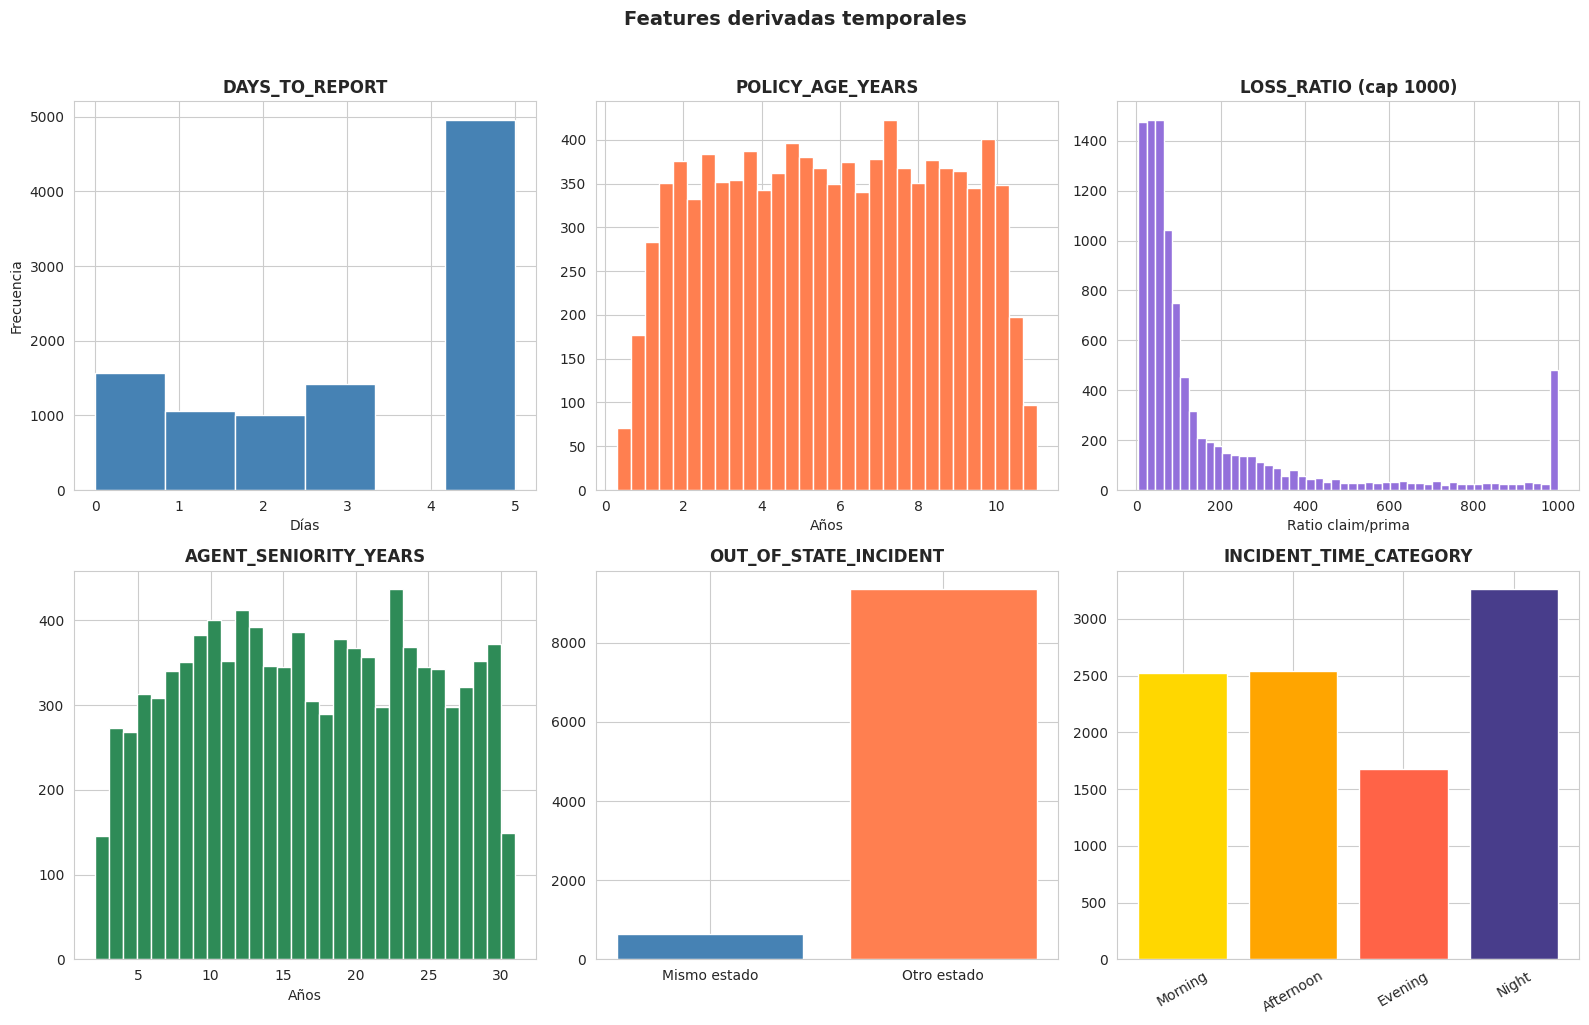

Gráfico guardado: features_derivadas.png


In [27]:
# =============================================================================
# VISUALIZACIÓN DE TODAS LAS FEATURES CREADAS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. DAYS_TO_REPORT
axes[0,0].hist(df['DAYS_TO_REPORT'], bins=6, color='steelblue', edgecolor='white')
axes[0,0].set_title('DAYS_TO_REPORT', fontweight='bold')
axes[0,0].set_xlabel('Días')
axes[0,0].set_ylabel('Frecuencia')

# 2. POLICY_AGE_YEARS
axes[0,1].hist(df['POLICY_AGE_YEARS'], bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('POLICY_AGE_YEARS', fontweight='bold')
axes[0,1].set_xlabel('Años')

# 3. LOSS_RATIO (capped para visibilidad)
axes[0,2].hist(df['LOSS_RATIO'].clip(upper=1000), bins=50, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('LOSS_RATIO (cap 1000)', fontweight='bold')
axes[0,2].set_xlabel('Ratio claim/prima')

# 4. AGENT_SENIORITY_YEARS
axes[1,0].hist(df['AGENT_SENIORITY_YEARS'], bins=30, color='seagreen', edgecolor='white')
axes[1,0].set_title('AGENT_SENIORITY_YEARS', fontweight='bold')
axes[1,0].set_xlabel('Años')

# 5. OUT_OF_STATE
labels_oos = ['Mismo estado', 'Otro estado']
vals_oos = [len(df[df['OUT_OF_STATE_INCIDENT']==0]), len(df[df['OUT_OF_STATE_INCIDENT']==1])]
axes[1,1].bar(labels_oos, vals_oos, color=['steelblue', 'coral'])
axes[1,1].set_title('OUT_OF_STATE_INCIDENT', fontweight='bold')

# 6. TIME_CATEGORY
cat_order = ['Morning', 'Afternoon', 'Evening', 'Night']
cat_counts = df['INCIDENT_TIME_CATEGORY'].value_counts().reindex(cat_order)
axes[1,2].bar(cat_order, cat_counts.values, color=['gold', 'orange', 'tomato', 'darkslateblue'])
axes[1,2].set_title('INCIDENT_TIME_CATEGORY', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=30)

plt.suptitle('Features derivadas temporales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('features_derivadas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: features_derivadas.png")


## 1.11 Persistencia del dataset integrado con features

Se guarda el dataset consolidado (3 tablas joineadas + features) en Parquet. Este es el archivo que consumen los notebooks de los puntos 2, 3 y 4.


In [28]:
# =============================================================================
# GUARDAR DATASET INTEGRADO + FEATURES EN PARQUET
# =============================================================================

output_path = os.path.join(PARQUET_DIR, 'insurance_integrated.parquet')
df.to_parquet(output_path, index=False, engine='pyarrow')

size_kb = os.path.getsize(output_path) / 1024
print(f"=== DATASET INTEGRADO GUARDADO ===")
print(f"  Archivo: {output_path}")
print(f"  Shape:   {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"  Tamaño:  {size_kb:.1f} KB")

print(f"\n=== COLUMNAS DEL DATASET INTEGRADO ===")
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    nulls = df[col].isnull().sum()
    null_str = f" (nulls: {nulls})" if nulls > 0 else ""
    print(f"  {i:>2}. {col:40s} {dtype:>15s}{null_str}")


=== DATASET INTEGRADO GUARDADO ===
  Archivo: ./parquet/insurance_integrated.parquet
  Shape:   10,000 filas × 60 columnas
  Tamaño:  1460.5 KB

=== COLUMNAS DEL DATASET INTEGRADO ===
   1. TXN_DATE_TIME                             datetime64[us]
   2. TRANSACTION_ID                                       str
   3. CUSTOMER_ID                                          str
   4. POLICY_NUMBER                                        str
   5. POLICY_EFF_DT                             datetime64[us]
   6. LOSS_DT                                   datetime64[us]
   7. REPORT_DT                                 datetime64[us]
   8. INSURANCE_TYPE                                       str
   9. PREMIUM_AMOUNT                                   float64
  10. CLAIM_AMOUNT                                       int64
  11. CUSTOMER_NAME                                        str
  12. ADDRESS_LINE1                                        str
  13. ADDRESS_LINE2                                        s

## 1.12 Consultas SQL sobre las tablas Parquet (DuckDB)

Para demostrar que las tablas Parquet quedan listas para explotación, se ejecutan consultas SQL directamente sobre los archivos usando **DuckDB** (motor SQL en memoria, no requiere servidor).

DuckDB lee Parquet nativamente, lo que permite hacer queries SQL sin cargar todo a memoria.


In [29]:
# =============================================================================
# CONEXIÓN DUCKDB — CONSULTAS SQL CONTRA PARQUET
# =============================================================================

con = duckdb.connect()

# Registrar las tablas Parquet como vistas SQL
con.execute(f"CREATE VIEW insurance AS SELECT * FROM read_parquet('{PARQUET_DIR}/insurance_data.parquet')")
con.execute(f"CREATE VIEW employee AS SELECT * FROM read_parquet('{PARQUET_DIR}/employee_data.parquet')")
con.execute(f"CREATE VIEW vendor AS SELECT * FROM read_parquet('{PARQUET_DIR}/vendor_data.parquet')")
con.execute(f"CREATE VIEW integrated AS SELECT * FROM read_parquet('{PARQUET_DIR}/insurance_integrated.parquet')")

print("✅ Vistas SQL creadas sobre Parquet:")
print("   - insurance  (insurance_data.parquet)")
print("   - employee   (employee_data.parquet)")
print("   - vendor     (vendor_data.parquet)")
print("   - integrated (insurance_integrated.parquet)")


✅ Vistas SQL creadas sobre Parquet:
   - insurance  (insurance_data.parquet)
   - employee   (employee_data.parquet)
   - vendor     (vendor_data.parquet)
   - integrated (insurance_integrated.parquet)


### SQL 1: Feature temporal — Días entre siniestro y reporte

In [30]:
# =============================================================================
# SQL 1: DAYS_TO_REPORT — calculado directamente desde Parquet
# =============================================================================

query_1 = """
SELECT
    TRANSACTION_ID,
    LOSS_DT,
    REPORT_DT,
    -- Feature temporal: días entre siniestro y reporte
    DATE_DIFF('day', LOSS_DT, REPORT_DT) AS days_to_report,
    CLAIM_AMOUNT,
    INSURANCE_TYPE,
    CLAIM_STATUS
FROM insurance
ORDER BY days_to_report DESC
LIMIT 10
"""

print("=== SQL 1: Feature DAYS_TO_REPORT ===")
print(con.execute(query_1).df().to_string(index=False))


=== SQL 1: Feature DAYS_TO_REPORT ===
TRANSACTION_ID    LOSS_DT  REPORT_DT  days_to_report  CLAIM_AMOUNT INSURANCE_TYPE CLAIM_STATUS
   TXN00000001 2020-05-16 2020-05-21               5          9000         Health            A
   TXN00000002 2020-05-13 2020-05-18               5         26000       Property            A
   TXN00000003 2020-05-21 2020-05-26               5         13000       Property            A
   TXN00000004 2020-05-14 2020-05-19               5         16000         Health            A
   TXN00000005 2020-05-17 2020-05-22               5          3000         Travel            A
   TXN00000006 2020-05-20 2020-05-25               5         63000           Life            A
   TXN00000007 2020-05-13 2020-05-18               5          3000         Health            A
   TXN00000008 2020-05-14 2020-05-19               5          8000          Motor            A
   TXN00000009 2020-05-21 2020-05-26               5          5000          Motor            A
   TXN000000

### SQL 2: Feature temporal — Antigüedad de la póliza al momento del siniestro

In [31]:
# =============================================================================
# SQL 2: POLICY_AGE_YEARS — antigüedad de la póliza
# =============================================================================

query_2 = """
SELECT
    TRANSACTION_ID,
    POLICY_EFF_DT,
    LOSS_DT,
    -- Feature temporal: antigüedad de la póliza en años
    ROUND(DATE_DIFF('day', POLICY_EFF_DT, LOSS_DT) / 365.25, 2) AS policy_age_years,
    CLAIM_AMOUNT,
    PREMIUM_AMOUNT,
    -- Feature: loss ratio
    ROUND(CLAIM_AMOUNT / PREMIUM_AMOUNT, 2) AS loss_ratio,
    CLAIM_STATUS
FROM insurance
WHERE CLAIM_AMOUNT / PREMIUM_AMOUNT > 500  -- solo los extremos
ORDER BY loss_ratio DESC
LIMIT 10
"""

print("=== SQL 2: Claims con LOSS_RATIO extremo (>500x) ===")
print(con.execute(query_2).df().to_string(index=False))


=== SQL 2: Claims con LOSS_RATIO extremo (>500x) ===


TRANSACTION_ID POLICY_EFF_DT    LOSS_DT  policy_age_years  CLAIM_AMOUNT  PREMIUM_AMOUNT  loss_ratio CLAIM_STATUS
   TXN00006897    2016-03-04 2021-02-10              4.94        100000           53.69     1862.54            A
   TXN00005513    2014-08-01 2020-12-22              6.39         96000           52.65     1823.36            A
   TXN00004641    2013-05-30 2020-11-28              7.50        100000           55.32     1807.66            A
   TXN00001351    2013-02-18 2020-07-16              7.41         91000           50.53     1800.91            A
   TXN00008114    2014-08-30 2021-04-16              6.63         99000           55.08     1797.39            A
   TXN00008915    2011-12-17 2021-05-14              9.41         91000           50.91     1787.47            A
   TXN00004302    2011-11-05 2020-11-02              8.99         93000           52.06     1786.40            A
   TXN00005933    2013-05-03 2021-01-06              7.68         98000           55.13     1777

### SQL 3: Feature temporal — Antigüedad del agente + JOIN con employee

In [32]:
# =============================================================================
# SQL 3: AGENT_SENIORITY — join insurance + employee
# =============================================================================

query_3 = """
SELECT
    i.TRANSACTION_ID,
    i.AGENT_ID,
    e.AGENT_NAME,
    e.DATE_OF_JOINING,
    i.TXN_DATE_TIME,
    -- Feature temporal: antigüedad del agente en años
    ROUND(DATE_DIFF('day', e.DATE_OF_JOINING, i.TXN_DATE_TIME) / 365.25, 2) AS agent_seniority_years,
    i.CLAIM_AMOUNT,
    i.CLAIM_STATUS
FROM insurance i
JOIN employee e ON i.AGENT_ID = e.AGENT_ID
ORDER BY agent_seniority_years ASC
LIMIT 10
"""

print("=== SQL 3: Agentes más nuevos (menor seniority) ===")
print(con.execute(query_3).df().to_string(index=False))


=== SQL 3: Agentes más nuevos (menor seniority) ===


TRANSACTION_ID   AGENT_ID      AGENT_NAME DATE_OF_JOINING TXN_DATE_TIME  agent_seniority_years  CLAIM_AMOUNT CLAIM_STATUS
   TXN00000804 AGENT01112  Patricia Short      2018-06-14    2020-07-02                   2.05          4000            A
   TXN00000118 AGENT00353    Sara Fincher      2018-05-12    2020-06-04                   2.06         21000            A
   TXN00001178 AGENT00942    Scott Clarke      2018-06-24    2020-07-16                   2.06          2000            A
   TXN00000726 AGENT00353    Sara Fincher      2018-05-12    2020-06-29                   2.13          4000            A
   TXN00000348 AGENT00583   Thomas Brauer      2018-04-25    2020-06-14                   2.14          4000            A
   TXN00000523 AGENT00583   Thomas Brauer      2018-04-25    2020-06-20                   2.15         10000            A
   TXN00002028 AGENT01112  Patricia Short      2018-06-14    2020-08-20                   2.18          9000            A
   TXN00000868 AGENT0005

### SQL 4: Resumen por tipo de seguro (consulta analítica)

In [33]:
# =============================================================================
# SQL 4: RESUMEN POR TIPO DE SEGURO — usando tabla integrada
# =============================================================================

query_4 = """
SELECT
    INSURANCE_TYPE,
    COUNT(*) AS total_claims,
    -- KPI: tasa de rechazo
    ROUND(SUM(CASE WHEN CLAIM_STATUS = 'D' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS denial_rate_pct,
    -- KPI: claim promedio
    ROUND(AVG(CLAIM_AMOUNT), 2) AS avg_claim,
    -- KPI: loss ratio promedio
    ROUND(AVG(CLAIM_AMOUNT / PREMIUM_AMOUNT), 2) AS avg_loss_ratio,
    -- Feature: días promedio de reporte
    ROUND(AVG(DAYS_TO_REPORT), 2) AS avg_days_to_report,
    -- Feature: % fuera de estado
    ROUND(AVG(OUT_OF_STATE_INCIDENT) * 100, 2) AS pct_out_of_state,
    -- % con vendor
    ROUND(AVG(HAS_VENDOR) * 100, 2) AS pct_has_vendor
FROM integrated
GROUP BY INSURANCE_TYPE
ORDER BY denial_rate_pct DESC
"""

print("=== SQL 4: Resumen por tipo de seguro ===")
result = con.execute(query_4).df()
display(result)


=== SQL 4: Resumen por tipo de seguro ===


,INSURANCE_TYPE,total_claims,denial_rate_pct,avg_claim,avg_loss_ratio,avg_days_to_report,pct_out_of_state,pct_has_vendor
0,Motor,1574,5.40,5503.81,54.66,3.21,93.77,69.00
1,Travel,1670,5.27,2979.64,41.61,3.18,92.63,68.02
2,Health,1690,5.03,10801.18,75.33,3.21,93.37,66.98
3,Mobile,1692,4.96,406.80,46.98,3.22,93.74,67.67
4,Property,1692,4.96,24573.88,213.97,3.25,94.44,65.90
5,Life,1682,4.58,54386.44,754.01,3.21,93.52,67.84


### SQL 5: Detección de claims sospechosos (multi-criterio)

In [34]:
# =============================================================================
# SQL 5: CLAIMS SOSPECHOSOS — criterios combinados
# =============================================================================

query_5 = """
SELECT
    TRANSACTION_ID,
    INSURANCE_TYPE,
    CLAIM_AMOUNT,
    PREMIUM_AMOUNT,
    ROUND(LOSS_RATIO, 2) AS loss_ratio,
    DAYS_TO_REPORT,
    ROUND(POLICY_AGE_YEARS, 2) AS policy_age_years,
    INCIDENT_SEVERITY,
    ANY_INJURY,
    POLICE_REPORT_AVAILABLE,
    HAS_VENDOR,
    OUT_OF_STATE_INCIDENT,
    CLAIM_STATUS,
    -- Score de sospecha: suma de red flags
    (CASE WHEN LOSS_RATIO > 500 THEN 1 ELSE 0 END
     + CASE WHEN DAYS_TO_REPORT = 0 THEN 1 ELSE 0 END
     + CASE WHEN ANY_INJURY = 0 AND INCIDENT_SEVERITY = 'Total Loss' THEN 1 ELSE 0 END
     + CASE WHEN POLICE_REPORT_AVAILABLE = 0 THEN 1 ELSE 0 END
     + CASE WHEN HAS_VENDOR = 0 THEN 1 ELSE 0 END
     + CASE WHEN POLICY_AGE_YEARS < 1 THEN 1 ELSE 0 END
    ) AS suspicion_score
FROM integrated
ORDER BY suspicion_score DESC, CLAIM_AMOUNT DESC
LIMIT 15
"""

print("=== SQL 5: Top 15 claims más sospechosos (score multi-criterio) ===")
result = con.execute(query_5).df()
display(result)
print(f"\nScore máximo: {result['suspicion_score'].max()}")
print(f"Claims con score >= 4: {con.execute('SELECT COUNT(*) FROM (' + query_5.replace('LIMIT 15','') + ') WHERE suspicion_score >= 4').fetchone()[0]}")


=== SQL 5: Top 15 claims más sospechosos (score multi-criterio) ===


,TRANSACTION_ID,INSURANCE_TYPE,CLAIM_AMOUNT,PREMIUM_AMOUNT,loss_ratio,DAYS_TO_REPORT,policy_age_years,INCIDENT_SEVERITY,ANY_INJURY,POLICE_REPORT_AVAILABLE,HAS_VENDOR,OUT_OF_STATE_INCIDENT,CLAIM_STATUS,suspicion_score
0,TXN00001683,Health,2000,183.66,10.89,0,0.63,Total Loss,0,0,0,1,A,5
1,TXN00000117,Life,100000,82.01,1219.36,3,0.42,Total Loss,0,0,1,1,A,4
2,TXN00001573,Life,99000,88.21,1122.32,5,8.52,Total Loss,0,0,0,1,D,4
3,TXN00003176,Life,99000,97.60,1014.34,0,8.77,Minor Loss,0,0,0,1,A,4
4,TXN00009848,Life,99000,88.02,1124.74,0,8.15,Major Loss,1,0,0,1,A,4
5,TXN00003563,Life,97000,99.67,973.21,0,10.06,Minor Loss,1,0,0,1,A,4
6,TXN00008898,Life,95000,55.82,1701.90,0,1.80,Total Loss,1,0,0,1,A,4
7,TXN00009443,Life,93000,84.67,1098.38,0,9.07,Total Loss,0,0,1,1,A,4
8,TXN00006831,Life,92000,73.52,1251.36,0,1.47,Minor Loss,1,0,0,1,A,4
9,TXN00009832,Life,91000,81.50,1116.56,0,5.54,Major Loss,1,0,0,1,A,4



Score máximo: 5
Claims con score >= 4: 69


In [35]:
# Cerrar conexión DuckDB
con.close()
print("✅ Conexión DuckDB cerrada")


✅ Conexión DuckDB cerrada


## 1.13 Resumen y archivos generados

### Problemas de calidad documentados

| # | Problema | Tipo | Registros | Resolución |
|---|----------|------|----------:|------------|
| 1 | Fechas como string | Tipo incorrecto | 11,200 | Casteo a `datetime64` |
| 2 | POSTAL_CODE sin leading zeros | Tipo incorrecto | 2,028 | `str` + `zfill(5)` |
| 3 | Nulls en categóricos | Datos faltantes | 2,574 | Imputación contextual |
| 4 | CLAIM_AMOUNT bucketeado | Granularidad | 10,000 | Documentado (no corregible) |
| 5 | TENURE no correlaciona con fechas | Inconsistencia semántica | 10,000 | Documentado + feature calculada |

### Features derivadas temporales

| # | Feature | Tipo | Cálculo SQL |
|---|---------|------|-------------|
| 1 | `DAYS_TO_REPORT` | Numérica | `DATE_DIFF('day', LOSS_DT, REPORT_DT)` |
| 2 | `POLICY_AGE_YEARS` | Numérica | `DATE_DIFF('day', POLICY_EFF_DT, LOSS_DT) / 365.25` |
| 3 | `LOSS_RATIO` | Numérica | `CLAIM_AMOUNT / PREMIUM_AMOUNT` |
| 4 | `AGENT_SENIORITY_YEARS` | Numérica | `DATE_DIFF('day', DATE_OF_JOINING, TXN_DATE_TIME) / 365.25` |
| 5 | `OUT_OF_STATE_INCIDENT` | Flag 0/1 | `CASE WHEN STATE != INCIDENT_STATE THEN 1 ELSE 0 END` |
| 6 | `INCIDENT_TIME_CATEGORY` | Categórica | `CASE` sobre `INCIDENT_HOUR_OF_THE_DAY` |

### Archivos generados

| Archivo | Contenido | Uso |
|---------|-----------|-----|
| `parquet/insurance_data.parquet` | insurance_data limpio (10,000 × 39) | Tabla de hechos normalizada |
| `parquet/employee_data.parquet` | employee_data limpio (1,200 × 10) | Maestro de agentes |
| `parquet/vendor_data.parquet` | vendor_data limpio (600 × 7) | Maestro de vendors |
| `parquet/insurance_integrated.parquet` | Dataset integrado + features (10,000 × 56) | **Input para puntos 2, 3 y 4** |

---

**Fin del punto 1. Las tablas están listas para explotación.**
